# Step 2: Eksplorasi Data (EDA)

Replikasi Tabel 2 (ringkasan fitur numerik) dan Tabel 3 (ringkasan fitur kategorikal) dari paper.

Fitur numerik (10): Administrative, Administrative_Duration, Informational, Informational_Duration, ProductRelated, ProductRelated_Duration, BounceRates, ExitRates, PageValues, SpecialDay

Fitur kategorikal (7): OperatingSystems, Browser, Region, TrafficType, VisitorType, Weekend, Month

In [1]:
import sys, os
sys.path.append('../src')
from data_utils import load_data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('../results/tables', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

df = load_data()
df.shape

(12330, 18)

## Ringkasan Fitur Numerik (replikasi Tabel 2)

In [2]:
numeric_features = [
    'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]

numeric_summary = pd.DataFrame({
    'min': df[numeric_features].min(),
    'max': df[numeric_features].max(),
    'mean': df[numeric_features].mean(),
    'std': df[numeric_features].std(),
})
numeric_summary = numeric_summary.round(2)
numeric_summary.to_csv('../results/tables/eda_numeric_summary.csv')
numeric_summary

,min,max,mean,std
Administrative,0.0,27.00,2.32,3.32
Administrative_Duration,0.0,3398.75,80.82,176.78
Informational,0.0,24.00,0.50,1.27
Informational_Duration,0.0,2549.38,34.47,140.75
ProductRelated,0.0,705.00,31.73,44.48
ProductRelated_Duration,0.0,63973.52,1194.75,1913.67
BounceRates,0.0,0.20,0.02,0.05
ExitRates,0.0,0.20,0.04,0.05
PageValues,0.0,361.76,5.89,18.57
SpecialDay,0.0,1.00,0.06,0.20


Bandingkan dengan Tabel 2 paper (std dari beberapa fitur, dibaca dari teks paper):
- Administrative_Duration: max=3398, std=176.70
- Content(Informational)_Duration: max=2549, std=140.64
- Product pages (ProductRelated): max=705, std=44.45
- Product pages duration: max=63973, std=1912.25
- Bounce rate: max=0.2, std=0.04
- Exit rate: max=0.2, std=0.05
- Page value: max=361, std=18.55
- Special day: max=1.0, std=0.19

In [3]:
paper_table2 = {
    'Administrative_Duration': {'max': 3398, 'std': 176.70},
    'Informational_Duration': {'max': 2549, 'std': 140.64},
    'ProductRelated': {'max': 705, 'std': 44.45},
    'ProductRelated_Duration': {'max': 63973, 'std': 1912.25},
    'BounceRates': {'max': 0.2, 'std': 0.04},
    'ExitRates': {'max': 0.2, 'std': 0.05},
    'PageValues': {'max': 361, 'std': 18.55},
    'SpecialDay': {'max': 1.0, 'std': 0.19},
}

print(f"{'Fitur':<28}{'Max Kita':>10}{'Max Paper':>12}{'Std Kita':>10}{'Std Paper':>12}")
for feat, vals in paper_table2.items():
    max_us = numeric_summary.loc[feat, 'max']
    std_us = numeric_summary.loc[feat, 'std']
    print(f"{feat:<28}{max_us:>10}{vals['max']:>12}{std_us:>10}{vals['std']:>12}")

Fitur                         Max Kita   Max Paper  Std Kita   Std Paper
Administrative_Duration        3398.75        3398    176.78       176.7
Informational_Duration         2549.38        2549    140.75      140.64
ProductRelated                   705.0         705     44.48       44.45
ProductRelated_Duration       63973.52       63973   1913.67     1912.25
BounceRates                        0.2         0.2      0.05        0.04
ExitRates                          0.2         0.2      0.05        0.05
PageValues                      361.76         361     18.57       18.55
SpecialDay                         1.0         1.0       0.2        0.19


## Ringkasan Fitur Kategorikal (replikasi Tabel 3)

In [4]:
categorical_features = ['OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Month']

cat_summary = pd.DataFrame({
    'n_levels': [df[c].nunique() for c in categorical_features],
}, index=categorical_features)
cat_summary.to_csv('../results/tables/eda_categorical_summary.csv')
cat_summary

,n_levels
OperatingSystems,8
Browser,13
Region,9
TrafficType,20
VisitorType,3
Weekend,2
Month,10


Bandingkan dengan Tabel 3 paper (jumlah level):
- OperatingSystems: 8
- Browser: 13
- Region (disebut 'Location' di paper): 9
- TrafficType: 20
- VisitorType: 3
- Weekend: 2
- Month: 12

In [5]:
paper_table3 = {
    'OperatingSystems': 8, 'Browser': 13, 'Region': 9, 'TrafficType': 20,
    'VisitorType': 3, 'Weekend': 2, 'Month': 12
}

print(f"{'Fitur':<20}{'Levels Kita':>14}{'Levels Paper':>16}{'Match?':>10}")
for feat, expected in paper_table3.items():
    actual = cat_summary.loc[feat, 'n_levels']
    match = 'OK' if actual == expected else 'CEK'
    print(f"{feat:<20}{actual:>14}{expected:>16}{match:>10}")

Fitur                  Levels Kita    Levels Paper    Match?
OperatingSystems                 8               8        OK
Browser                         13              13        OK
Region                           9               9        OK
TrafficType                     20              20        OK
VisitorType                      3               3        OK
Weekend                          2               2        OK
Month                           10              12       CEK


### Catatan Temuan: Month hanya 10 level (sudah dikonfirmasi TIDAK menyebabkan penyimpangan)

Dataset UCI yang kita unduh secara aktual **tidak memiliki sesi untuk bulan Januari dan April** — hanya 10 bulan yang muncul: Feb, Mar, May, June, Jul, Aug, Sep, Oct, Nov, Dec. Ini dikonfirmasi sebagai karakteristik asli dataset UCI id=468 (bukan bug), didukung juga oleh analisis publik independen lain terhadap dataset yang sama.

**Cross-check total fitur (28) sudah dilakukan dan HASILNYA COCOK.** Awalnya kami kira paper melakukan one-hot encoding pada semua 7 fitur kategorikal, sehingga 12 vs 10 level Month akan mengubah total fitur. Setelah menelusuri daftar 20 fitur signifikan yang disebut paper (berisi nama seperti `Region`, `Browser`, `OperatingSystems`, `TrafficType` tanpa suffix, tapi `Month_May`, `VisitorType_New_Visitor` dengan suffix), ternyata:
- **Hanya `Month` dan `VisitorType`** (fitur kategorikal berbentuk string) yang di-one-hot encoding.
- `OperatingSystems`, `Browser`, `Region`, `TrafficType` (sudah berupa kode integer) dan `Weekend` (sudah biner) dipakai **apa adanya**, tidak di-one-hot.

Rekonstruksi: 10 numerik + 1 Weekend + 4 kategorikal-kode-apa-adanya (OS, Browser, Region, TrafficType) + 10 dummy Month (10 level aktual) + 3 dummy VisitorType = **28 fitur, pas sesuai klaim paper**. Bukti tambahan: `Month_Nov` tidak masuk daftar 20 fitur signifikan paper — bukan karena datanya tidak ada, tapi karena November memang tidak lolos seleksi χ² sebagai fitur signifikan, konsisten dengan skenario 10 level Month.

**Kesimpulan: tidak ada penyimpangan.** Pendekatan Step 3 (preprocessing) akan mengikuti skema ini: one-hot encoding hanya untuk `Month` dan `VisitorType`, fitur kategorikal berkode integer lainnya dipakai langsung.

## Distribusi Kelas Revenue

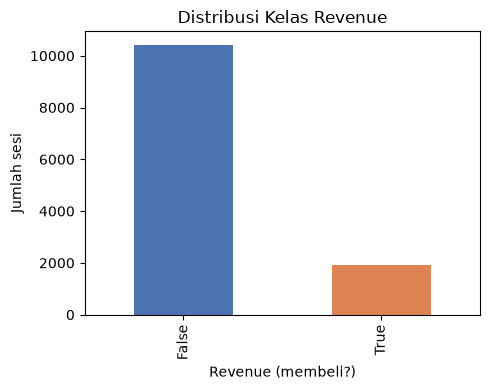

In [6]:
fig, ax = plt.subplots(figsize=(5,4))
df['Revenue'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Distribusi Kelas Revenue')
ax.set_xlabel('Revenue (membeli?)')
ax.set_ylabel('Jumlah sesi')
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=120)
plt.show()

## Distribusi Fitur Numerik (histogram)

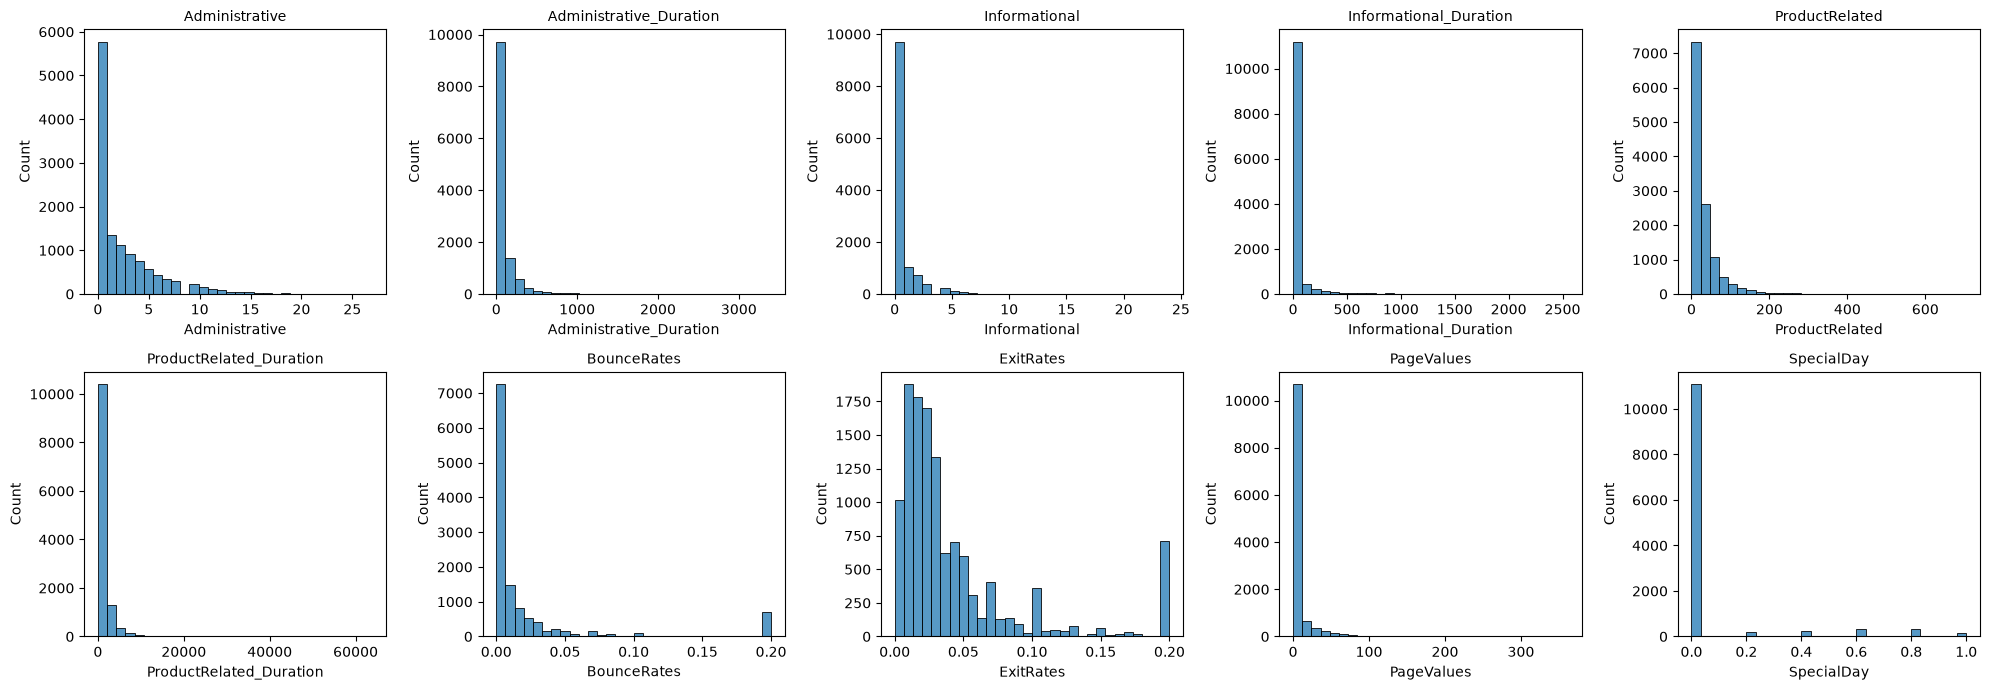

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, feat in zip(axes.flatten(), numeric_features):
    sns.histplot(df[feat], bins=30, ax=ax)
    ax.set_title(feat, fontsize=10)
plt.tight_layout()
plt.savefig('../results/figures/numeric_histograms.png', dpi=120)
plt.show()

In [8]:
print('EDA selesai. File tersimpan:')
print('- results/tables/eda_numeric_summary.csv')
print('- results/tables/eda_categorical_summary.csv')
print('- results/figures/class_distribution.png')
print('- results/figures/numeric_histograms.png')

EDA selesai. File tersimpan:
- results/tables/eda_numeric_summary.csv
- results/tables/eda_categorical_summary.csv
- results/figures/class_distribution.png
- results/figures/numeric_histograms.png
